# Customer Churn Prediction Project

**My Objective:** I wanted to build a complete machine learning project to predict which telecom customers might leave us (churn). Then, I'll use what the model learned to come up with ideas to keep them.

**Dataset Used:** IBM Telco Customer Churn (I'm looking at 7,043 customers and 21 different features).

**What I did in this notebook:**
1. Data Loading & Exploratory Data Analysis (EDA)
2. Data Preprocessing & Feature Engineering
3. Model Development & Hyperparameter Tuning
4. Model Evaluation & Business Interpretation


## 1. Data Loading & Exploratory Data Analysis (EDA)

In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Publication-quality plotting defaults
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 10

pd.set_option("display.max_columns", None)

# Resolve paths relative to the notebook's location
current_dir = os.getcwd()
PROJECT_ROOT = os.path.dirname(current_dir) if os.path.basename(current_dir) == "notebooks" else current_dir
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "Telco-Customer-Churn.csv")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
PLOTS_DIR = os.path.join(PROJECT_ROOT, "notebooks")


### 1.1 Load Raw Data

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Shape: {df_raw.shape}")
df_raw.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1.2 Cleaning the Data: fixing `TotalCharges`

While exploring the dataset, I noticed `TotalCharges` was saved as a **string** instead of a number. Also, there were 11 brand-new customers (where `tenure == 0`) that just had a **blank space `" "`** because they hadn't been billed yet. So, I decided to convert this column to a numeric format and fill those blanks with `0` since they basically haven't spent anything yet.


In [3]:
# How many blank-string TotalCharges are there, and what do they have in common?
blank_mask = df_raw["TotalCharges"].astype(str).str.strip() == ""
print(f"Blank TotalCharges rows: {blank_mask.sum()}")
print("Tenure distribution for those rows:")
print(df_raw.loc[blank_mask, "tenure"].value_counts())


Blank TotalCharges rows: 11
Tenure distribution for those rows:
tenure
0    11
Name: count, dtype: int64


In [4]:
df = df_raw.copy()
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("TotalCharges dtype after cleaning:", df["TotalCharges"].dtype)
print("Remaining missing values:", df["TotalCharges"].isna().sum())


TotalCharges dtype after cleaning: float64
Remaining missing values: 0


### 1.3 Dataset Assessment

In [5]:
print("Shape:", df.shape)
print("\nMissing values per column:")
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() else "None")
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:")
print(df.dtypes)


Shape: (7043, 21)

Missing values per column:
None

Duplicate rows: 0

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


In [6]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.4 Visualization 1 — Churn Distribution

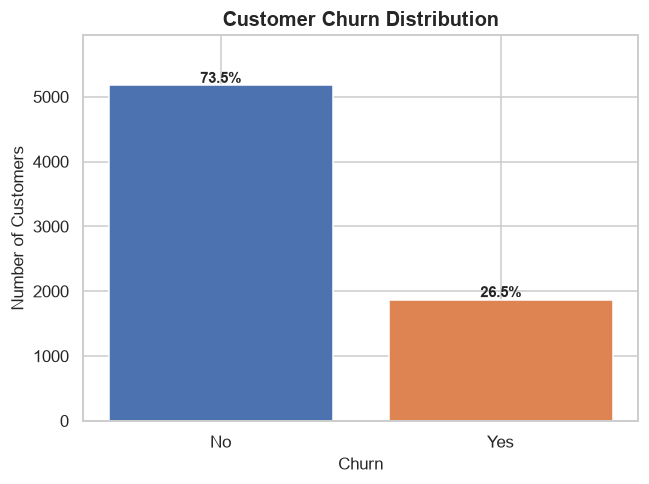

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.5))
churn_counts = df["Churn"].value_counts()
churn_pct = (churn_counts / churn_counts.sum() * 100).round(1)

bars = ax.bar(churn_counts.index, churn_counts.values,
               color=["#4C72B0", "#DD8452"])
for bar, pct in zip(bars, churn_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
            f"{pct}%", ha="center", fontweight="bold")

ax.set_title("Customer Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of Customers")
ax.set_ylim(0, churn_counts.max() * 1.15)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "plot_01_churn_distribution.png"), bbox_inches="tight")
plt.show()


### 1.5 Visualization 2 — Customer Tenure vs Churn

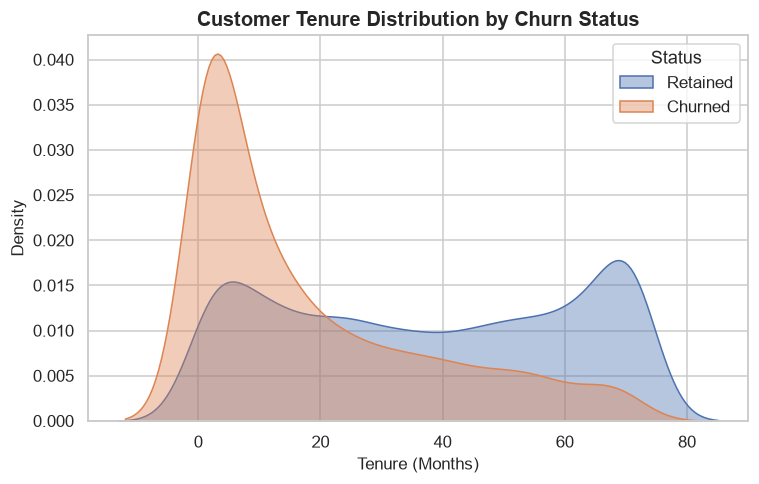

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for churn_val, color, label in [("No", "#4C72B0", "Retained"), ("Yes", "#DD8452", "Churned")]:
    sns.kdeplot(df.loc[df["Churn"] == churn_val, "tenure"], fill=True,
                alpha=0.4, label=label, color=color, ax=ax)

ax.set_title("Customer Tenure Distribution by Churn Status")
ax.set_xlabel("Tenure (Months)")
ax.set_ylabel("Density")
ax.legend(title="Status")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "plot_02_tenure_vs_churn.png"), bbox_inches="tight")
plt.show()


### 1.6 Visualization 3 — Monthly Charges vs Churn

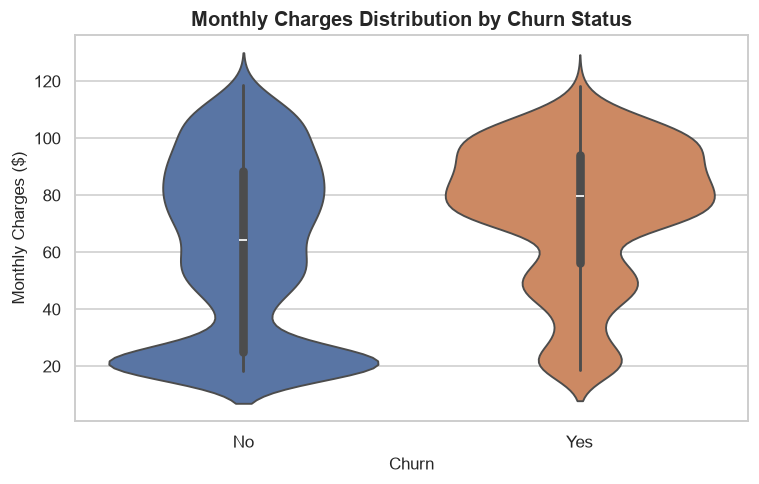

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.violinplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn",
                palette={"No": "#4C72B0", "Yes": "#DD8452"}, legend=False, ax=ax)
ax.set_title("Monthly Charges Distribution by Churn Status")
ax.set_xlabel("Churn")
ax.set_ylabel("Monthly Charges ($)")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "plot_03_monthlycharges_vs_churn.png"), bbox_inches="tight")
plt.show()


### 1.7 Visualization 4 — Churn Rate by Contract Type & Payment Method

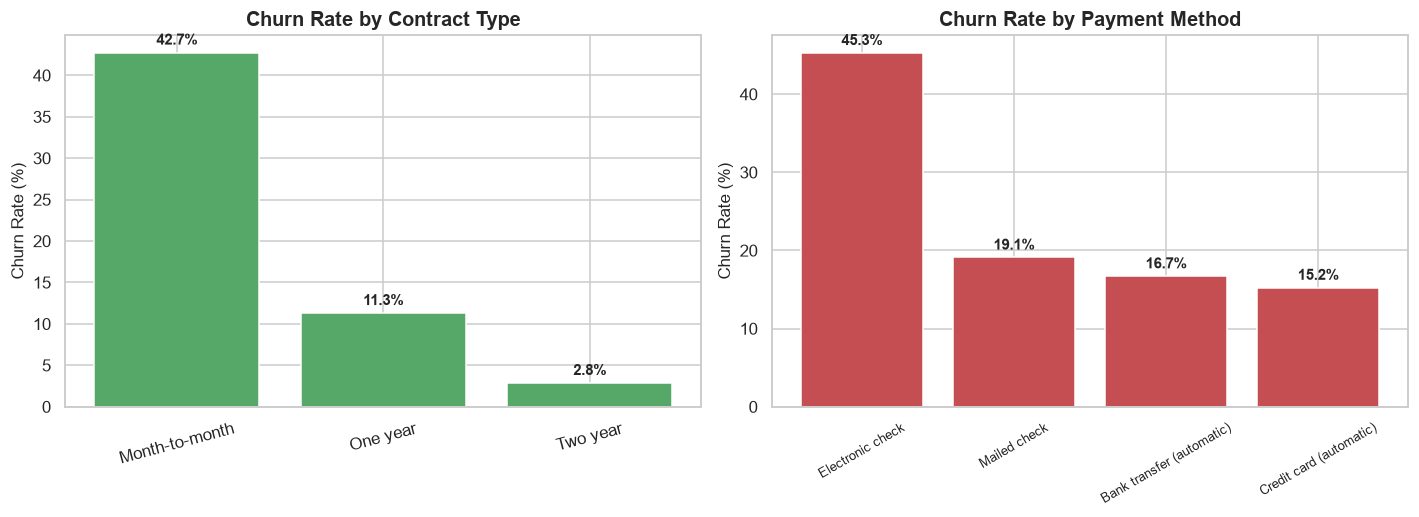

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

contract_churn = (df.groupby("Contract")["Churn"]
                     .apply(lambda s: (s == "Yes").mean() * 100)
                     .sort_values(ascending=False))
axes[0].bar(contract_churn.index, contract_churn.values, color="#55A868")
axes[0].set_title("Churn Rate by Contract Type")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(contract_churn.values):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

payment_churn = (df.groupby("PaymentMethod")["Churn"]
                    .apply(lambda s: (s == "Yes").mean() * 100)
                    .sort_values(ascending=False))
axes[1].bar(payment_churn.index, payment_churn.values, color="#C44E52")
axes[1].set_title("Churn Rate by Payment Method")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].tick_params(axis="x", rotation=30, labelsize=8.5)
for i, v in enumerate(payment_churn.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "plot_04_churn_by_contract_payment.png"), bbox_inches="tight")
plt.show()


### 1.8 Visualization 5 — Correlation Heatmap

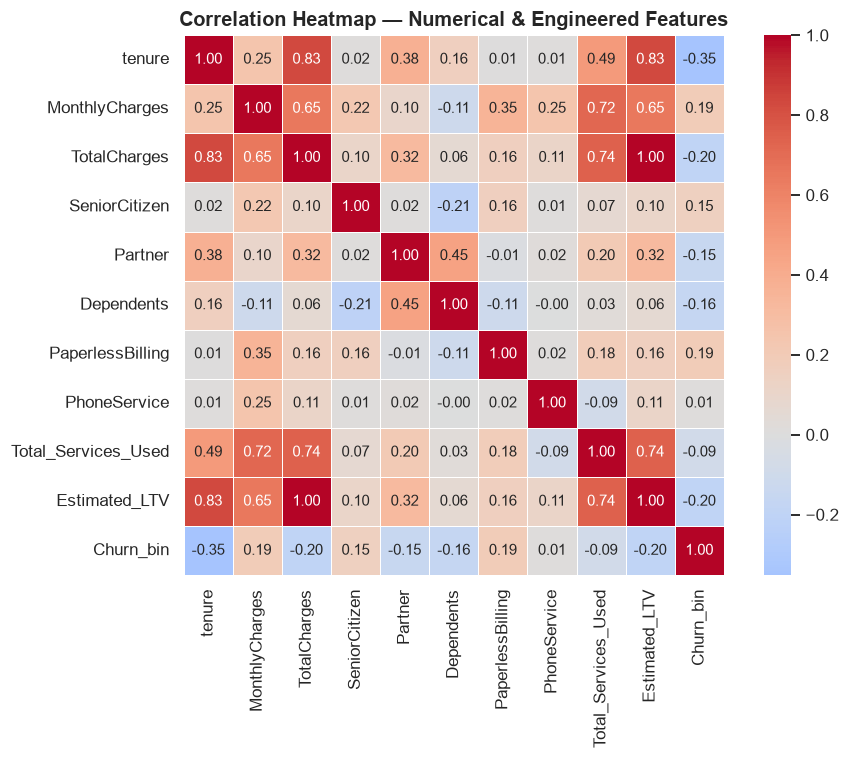

In [11]:
corr_df = df.copy()
corr_df["Churn_bin"] = (corr_df["Churn"] == "Yes").astype(int)

binary_map_cols = ["Partner", "Dependents", "PaperlessBilling", "PhoneService"]
for c in binary_map_cols:
    corr_df[c] = corr_df[c].map({"Yes": 1, "No": 0})

corr_df["Total_Services_Used"] = (df[["OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]] == "Yes").sum(axis=1)
corr_df["Estimated_LTV"] = corr_df["MonthlyCharges"] * corr_df["tenure"]

numeric_for_corr = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen",
                     "Partner", "Dependents", "PaperlessBilling", "PhoneService",
                     "Total_Services_Used", "Estimated_LTV", "Churn_bin"]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_df[numeric_for_corr].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title("Correlation Heatmap — Numerical & Engineered Features")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "plot_05_correlation_heatmap.png"), bbox_inches="tight")
plt.show()


### 1.9 Visualization 6 — Add-on Service Distributions

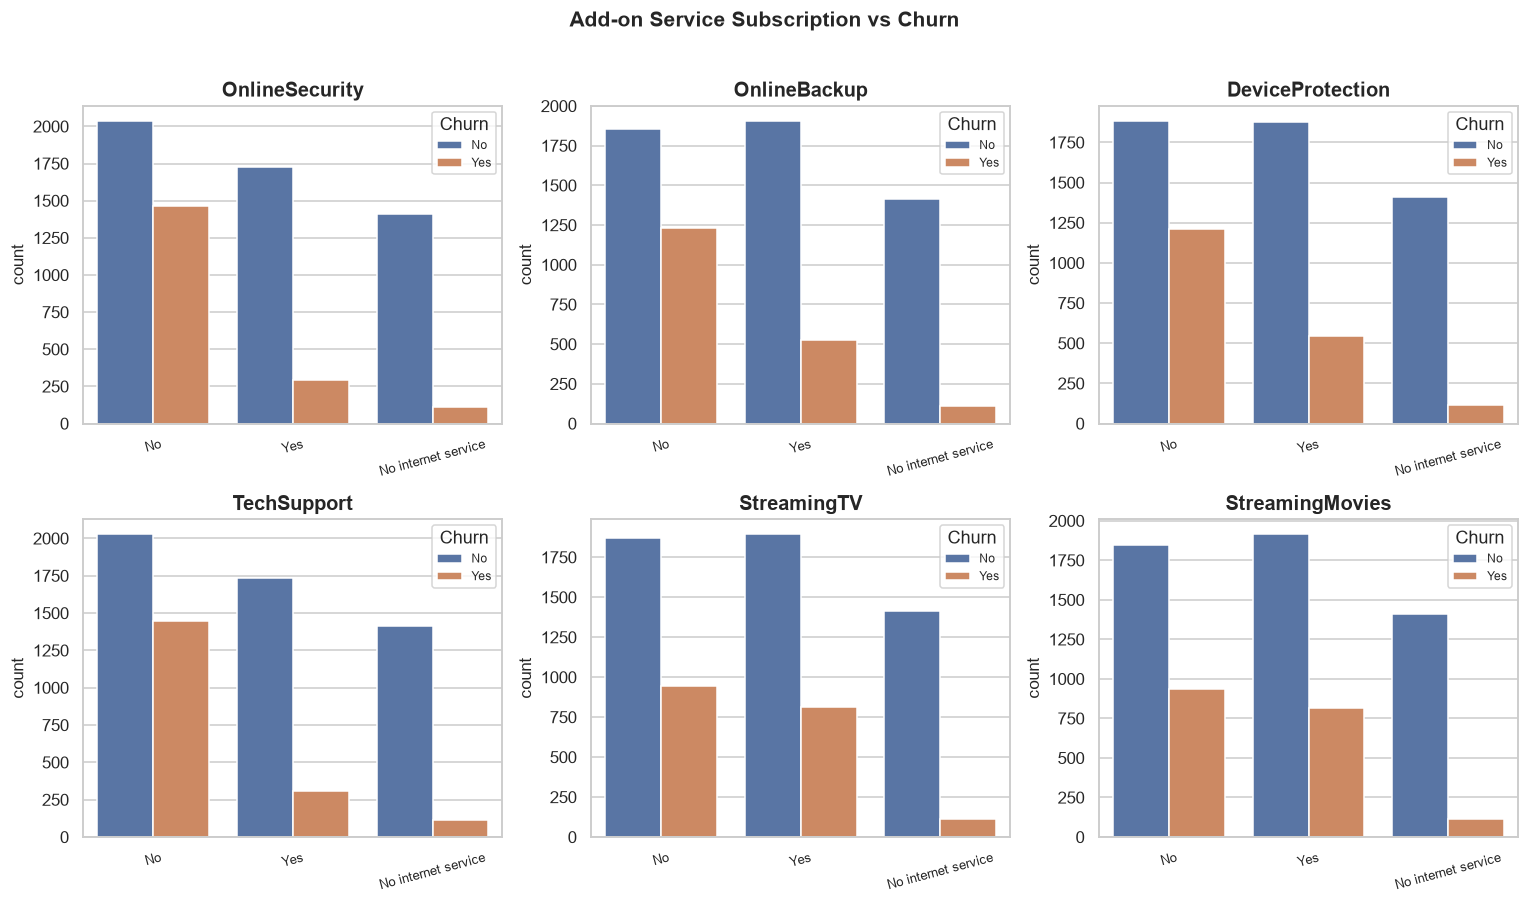

In [12]:
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV", "StreamingMovies"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(addon_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue="Churn", order=order,
                   palette={"No": "#4C72B0", "Yes": "#DD8452"}, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=15, labelsize=8.5)
    axes[i].legend(title="Churn", fontsize=8)

plt.suptitle("Add-on Service Subscription vs Churn", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "plot_06_addon_services.png"), bbox_inches="tight")
plt.show()


### 1.10 What I found out from the Data (My Insights)

1. **Contract type really matters.** I saw that customers on month-to-month contracts leave way more often than those on yearly contracts. It makes sense because they can leave anytime without penalty.
2. **Newer customers are at higher risk.** A lot of people seem to churn in their first year. If we can keep them past the first 12 months, they usually stay longer.
3. **Payment method plays a role.** People paying by electronic checks churned a lot more compared to those on automatic payments. Maybe they're just less engaged?
4. **Fiber optic vs DSL:** Interestingly, Fiber optic users churned more than DSL users, even though it's supposed to be better. It could be because it's more expensive or maybe there are service issues.
5. **Add-on services help keep customers.** Customers who didn't have extra services like Tech Support or Online Security were more likely to leave. It seems like having these add-ons makes them right at home.
6. **High bills lead to churn.** Higher monthly charges generally mean higher churn, especially for newer customers on flexible contracts. This group is definitely the highest risk.


## 2. Data Preprocessing & Feature Engineering

### 2.1 Making New Features (Feature Engineering)

I wanted to extract more value from the data, so I created four new features to better capture customer behavior and risk:

| Feature | Description |
|---|---|
| `Total_Services_Used` | Count of subscribed add-on services (0–6) |
| `Estimated_LTV` | `MonthlyCharges * tenure` — proxy for cumulative customer value |
| `Tenure_Group` | Categorical bucket: 0-12 / 12-24 / 24-48 / 48+ months |
| `Payment_Risk_Score` | 1 = manual payment method (higher churn risk), 0 = automatic |


In [13]:
# 1. Total_Services_Used
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV", "StreamingMovies"]
df["Total_Services_Used"] = (df[addon_cols] == "Yes").sum(axis=1)

# 2. Estimated_LTV
df["Estimated_LTV"] = df["MonthlyCharges"] * df["tenure"]

# 3. Tenure_Group
bins = [-1, 12, 24, 48, np.inf]
labels = ["0-12 Months", "12-24 Months", "24-48 Months", "48+ Months"]
df["Tenure_Group"] = pd.cut(df["tenure"], bins=bins, labels=labels)

# 4. Payment_Risk_Score
automatic_methods = {"Bank transfer (automatic)", "Credit card (automatic)"}
df["Payment_Risk_Score"] = df["PaymentMethod"].apply(lambda x: 0 if x in automatic_methods else 1)

df[["tenure", "Total_Services_Used", "Estimated_LTV", "Tenure_Group", "Payment_Risk_Score"]].head()


,tenure,Total_Services_Used,Estimated_LTV,Tenure_Group,Payment_Risk_Score
0,1,1,29.85,0-12 Months,1
1,34,2,1936.30,24-48 Months,1
2,2,2,107.70,0-12 Months,1
3,45,3,1903.50,24-48 Months,0
4,2,0,141.40,0-12 Months,1


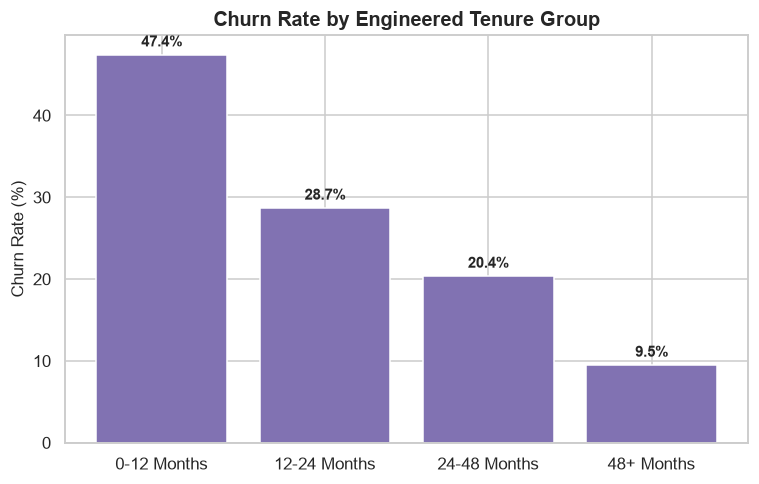

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
tg_churn = (df.groupby("Tenure_Group", observed=True)["Churn"]
              .apply(lambda s: (s == "Yes").mean() * 100))
ax.bar(tg_churn.index.astype(str), tg_churn.values, color="#8172B2")
ax.set_title("Churn Rate by Engineered Tenure Group")
ax.set_ylabel("Churn Rate (%)")
for i, v in enumerate(tg_churn.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "plot_07_tenure_group_churn.png"), bbox_inches="tight")
plt.show()


### 2.2 Preparing the Data for Models

Before I could train any models, I needed to get the data in the right format:
- **Target**: I changed `Churn` to numbers (`Yes` → 1, `No` → 0)
- **Yes/No features**: Mapped things like `Partner` and `Dependents` to 0/1
- **Categorical features**: I used one-hot encoding for columns like `PaymentMethod`
- **Number features**: I used standard scaling for continuous things like `tenure` and `MonthlyCharges` so they're on the same scale.
- **Splitting the data**: I did a standard 80/20 train/test split, making sure to stratify the `Churn` target so the proportions stay the same in both sets.


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

binary_cols = ["Partner", "Dependents", "PaperlessBilling"]
nominal_cols = ["gender", "MultipleLines", "InternetService", "OnlineSecurity",
                "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV",
                "StreamingMovies", "Contract", "PaymentMethod", "PhoneService"]
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Total_Services_Used", "Estimated_LTV"]

y = df["Churn"].astype(int)
X = df.drop(columns=["Churn", "customerID"])

for col in binary_cols:
    X[col] = X[col].map({"Yes": 1, "No": 0})

X = pd.get_dummies(X, columns=nominal_cols + ["Tenure_Group"], drop_first=True)
X = X.astype({c: "float64" for c in X.select_dtypes(include=["bool"]).columns})

print("Final feature matrix shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f} | Test churn rate: {y_test.mean():.3f}")

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])


Final feature matrix shape: (7043, 36)


Train: (5634, 36), Test: (1409, 36)
Train churn rate: 0.265 | Test churn rate: 0.265


## 3. Model Development & Hyperparameter Tuning

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)

def evaluate(model, X_te, y_te, name):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_te)
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_te, y_pred), 4),
        "Precision": round(precision_score(y_te, y_pred), 4),
        "Recall": round(recall_score(y_te, y_pred), 4),
        "F1-Score": round(f1_score(y_te, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_te, y_proba), 4),
    }

results = []
fitted_models = {}


### 3.1 Baseline Model — Logistic Regression

In [17]:
lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_scaled, y_train)
results.append(evaluate(lr, X_test_scaled, y_test, "Logistic Regression (Baseline)"))
fitted_models["Logistic Regression (Baseline)"] = lr
pd.DataFrame(results)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Baseline),0.7999,0.6554,0.5187,0.5791,0.8424


### 3.2 Advanced Models

In [18]:
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train_scaled, y_train)
results.append(evaluate(dt, X_test_scaled, y_test, "Decision Tree"))
fitted_models["Decision Tree"] = dt

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
results.append(evaluate(rf, X_test_scaled, y_test, "Random Forest (Default)"))
fitted_models["Random Forest (Default)"] = rf

# Gradient Boosting — sklearn's native implementation (distinct from XGBoost)
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                 max_depth=4, random_state=42)
gb.fit(X_train_scaled, y_train)
results.append(evaluate(gb, X_test_scaled, y_test, "Gradient Boosting"))
fitted_models["Gradient Boosting"] = gb

xgb = XGBClassifier(n_estimators=200, eval_metric="logloss", random_state=42)
xgb.fit(X_train_scaled, y_train)
results.append(evaluate(xgb, X_test_scaled, y_test, "XGBoost (Default)"))
fitted_models["XGBoost (Default)"] = xgb

svm = SVC(probability=True, kernel="rbf", random_state=42)
svm.fit(X_train_scaled, y_train)
results.append(evaluate(svm, X_test_scaled, y_test, "SVM (RBF)"))
fitted_models["SVM (RBF)"] = svm

pd.DataFrame(results)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Baseline),0.7999,0.6554,0.5187,0.5791,0.8424
1,Decision Tree,0.8006,0.6667,0.4973,0.5697,0.8213
2,Random Forest (Default),0.7885,0.6258,0.5053,0.5592,0.8234
3,Gradient Boosting,0.8013,0.6577,0.5241,0.5833,0.8447
4,XGBoost (Default),0.7708,0.5780,0.5053,0.5392,0.8120
5,SVM (RBF),0.7984,0.6654,0.4840,0.5604,0.7979


### 3.3 Tuning the Models

To get the best performance, I tried to find the best hyperparameters. I used two different approaches based on my experience:

- **`GridSearchCV`** for the Decision Tree. Since the search space isn't too huge, I let it check every single combination.
- **`RandomizedSearchCV`** for Random Forest and XGBoost. These models have way too many parameters, so testing every combination would take forever. Randomized search is a great shortcut that still finds good parameters quickly.

For both, I used 5-fold cross-validation and optimized for **ROC-AUC**.


In [19]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_param_dist = {
    "n_estimators": [200, 300, 400],
    "max_depth": [5, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist, n_iter=10, scoring="roc_auc",
    cv=cv, random_state=42, n_jobs=-1,
)
rf_search.fit(X_train_scaled, y_train)
rf_tuned = rf_search.best_estimator_
results.append(evaluate(rf_tuned, X_test_scaled, y_test, "Random Forest (Tuned)"))
fitted_models["Random Forest (Tuned)"] = rf_tuned
print("Best RF params:", rf_search.best_params_)
print("Best RF CV ROC-AUC:", round(rf_search.best_score_, 4))


Best RF params: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 8, 'class_weight': 'balanced'}
Best RF CV ROC-AUC: 0.8452


In [20]:
xgb_param_dist = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "scale_pos_weight": [1, 2, 2.77],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    param_distributions=xgb_param_dist, n_iter=10, scoring="roc_auc",
    cv=cv, random_state=42, n_jobs=-1,
)
xgb_search.fit(X_train_scaled, y_train)
xgb_tuned = xgb_search.best_estimator_
results.append(evaluate(xgb_tuned, X_test_scaled, y_test, "XGBoost (Tuned)"))
fitted_models["XGBoost (Tuned)"] = xgb_tuned
print("Best XGB params:", xgb_search.best_params_)
print("Best XGB CV ROC-AUC:", round(xgb_search.best_score_, 4))


Best XGB params: {'subsample': 0.9, 'scale_pos_weight': 1, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
Best XGB CV ROC-AUC: 0.8486


### 3.3c Grid Search on Decision Tree

Like I mentioned, I used `GridSearchCV` here to check all 90 possible combinations. It's totally doable for a simpler model like this one!


In [21]:
from sklearn.model_selection import GridSearchCV

dt_param_grid = {
    "max_depth": [3, 5, 6, 8, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"],
}
dt_grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    scoring="roc_auc", cv=cv, n_jobs=-1,
)
dt_grid_search.fit(X_train_scaled, y_train)
dt_grid_tuned = dt_grid_search.best_estimator_
results.append(evaluate(dt_grid_tuned, X_test_scaled, y_test, "Decision Tree (GridSearchCV)"))
fitted_models["Decision Tree (GridSearchCV)"] = dt_grid_tuned
print("Best DT params:", dt_grid_search.best_params_)
print(f"Best DT CV ROC-AUC: {dt_grid_search.best_score_:.4f}")
print(f"Total combinations evaluated: {len(dt_grid_search.cv_results_['params'])}")


Best DT params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best DT CV ROC-AUC: 0.8296
Total combinations evaluated: 90


### 3.4 Model Comparison & Champion Selection

In [22]:
comparison_df = pd.DataFrame(results).sort_values(
    by=["ROC-AUC", "Recall"], ascending=False).reset_index(drop=True)
comparison_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost (Tuned),0.8034,0.6714,0.5080,0.5784,0.8458
1,Gradient Boosting,0.8013,0.6577,0.5241,0.5833,0.8447
2,Random Forest (Tuned),0.7530,0.5230,0.7888,0.6290,0.8443
3,Logistic Regression (Baseline),0.7999,0.6554,0.5187,0.5791,0.8424
4,Decision Tree (GridSearchCV),0.7942,0.6312,0.5401,0.5821,0.8267
5,Random Forest (Default),0.7885,0.6258,0.5053,0.5592,0.8234
6,Decision Tree,0.8006,0.6667,0.4973,0.5697,0.8213
7,XGBoost (Default),0.7708,0.5780,0.5053,0.5392,0.8120
8,SVM (RBF),0.7984,0.6654,0.4840,0.5604,0.7979


In [23]:
champion_name = comparison_df.iloc[0]["Model"]
champion_model = fitted_models[champion_name]
print(f"CHAMPION MODEL: {champion_name}")
print(comparison_df.iloc[0])


CHAMPION MODEL: XGBoost (Tuned)
Model        XGBoost (Tuned)
Accuracy              0.8034
Precision             0.6714
Recall                 0.508
F1-Score              0.5784
ROC-AUC               0.8458
Name: 0, dtype: object


## 4. Model Evaluation & Business Interpretation

### 4.1 Confusion Matrices — Top Models

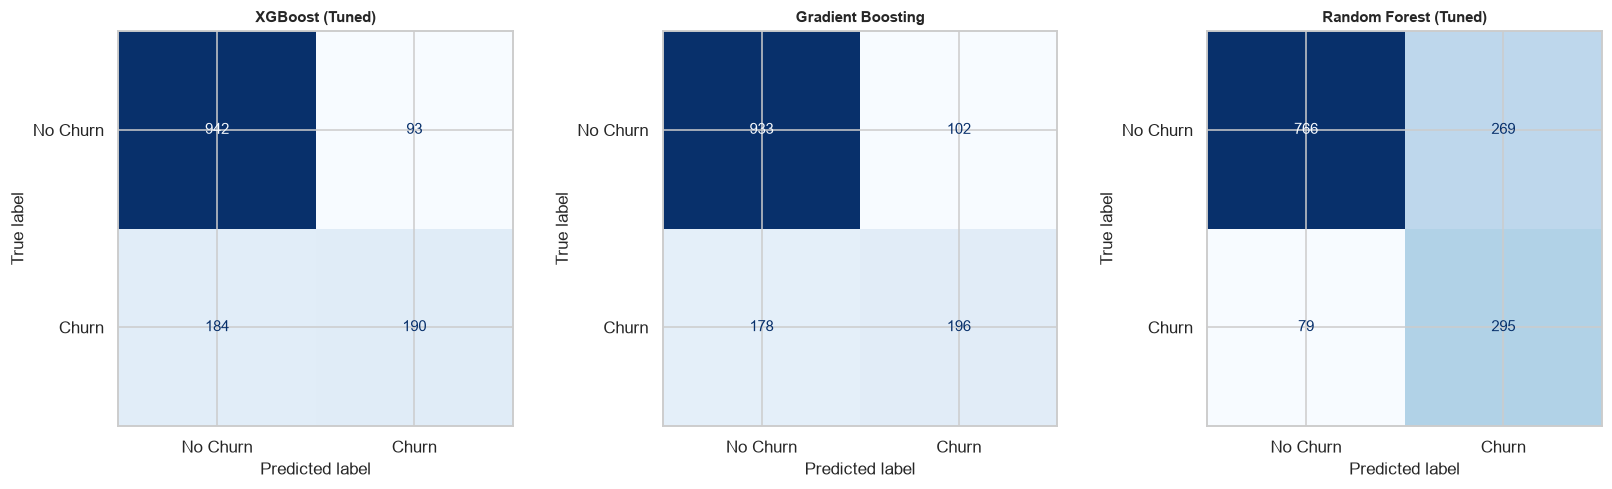

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

top_model_names = comparison_df["Model"].head(3).tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, top_model_names):
    model = fitted_models[name]
    cm = confusion_matrix(y_test, model.predict(X_test_scaled))
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "plot_08_confusion_matrices.png"), bbox_inches="tight")
plt.show()


### 4.2 ROC Curve Comparison

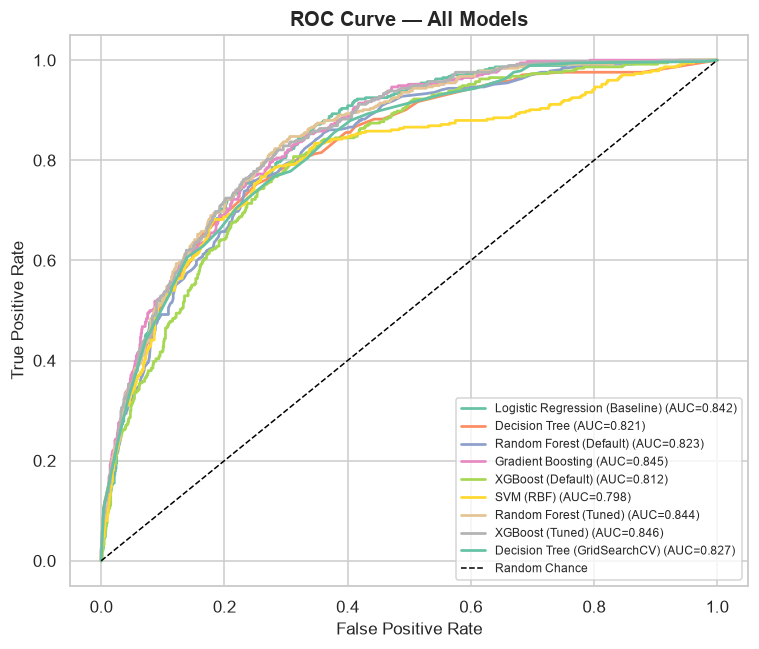

In [25]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(7, 6))
for name, model in fitted_models.items():
    proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.3f})", linewidth=1.8)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — All Models")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "plot_09_roc_curves.png"), bbox_inches="tight")
plt.show()


### 4.3 Precision-Recall Curve

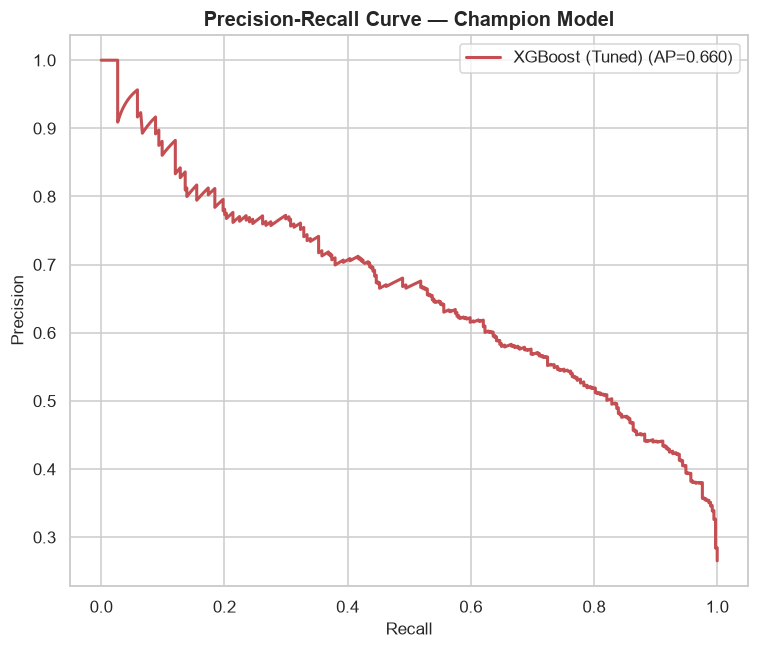

In [26]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(7, 6))
proba = champion_model.predict_proba(X_test_scaled)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)
ax.plot(recall, precision, linewidth=2, color="#C44E52", label=f"{champion_name} (AP={ap:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Champion Model")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "plot_10_precision_recall_curve.png"), bbox_inches="tight")
plt.show()


### 4.4 Top 10 Feature Importance

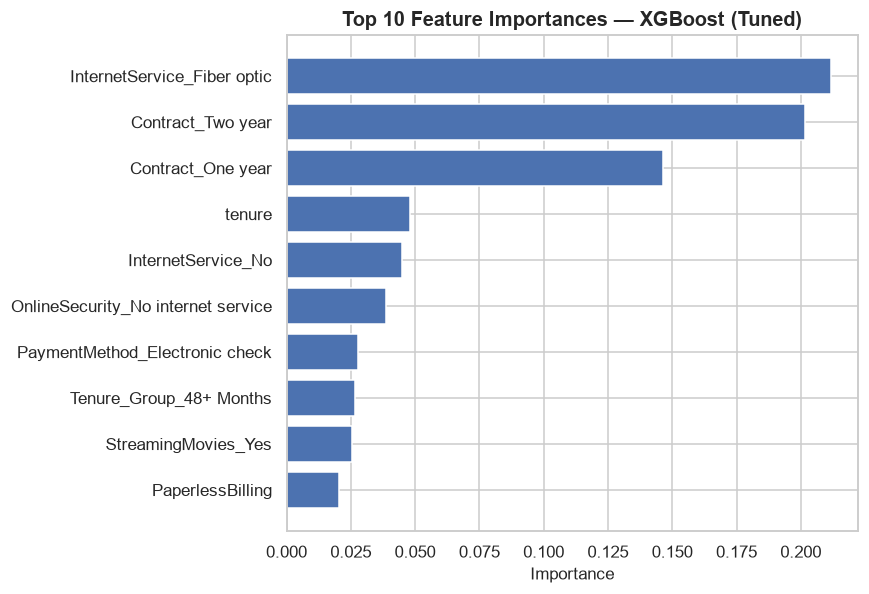

Saved top10_feature_importance.csv to models/


In [27]:
import joblib

if hasattr(champion_model, "feature_importances_"):
    importances = pd.Series(champion_model.feature_importances_, index=X_train_scaled.columns)
else:
    importances = pd.Series(np.abs(champion_model.coef_[0]), index=X_train_scaled.columns)

top10 = importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top10.index[::-1], top10.values[::-1], color="#4C72B0")
ax.set_title(f"Top 10 Feature Importances — {champion_name}")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "plot_11_feature_importance.png"), bbox_inches="tight")
plt.show()

# Save for PDF report
top10.reset_index().to_csv(os.path.join(MODELS_DIR, "top10_feature_importance.csv"), index=False)
print("Saved top10_feature_importance.csv to models/")


### 4.5 Thinking about Errors (Cost-Benefit Analysis)

When dealing with churn, I realized that making a mistake isn't equally bad in both directions:

- **False Positive** (saying someone will churn when they won't): The cost here is just a wasted discount or a phone call. It's not a big deal.
- **False Negative** (missing a real churner): This is the bad one. If we fail to spot someone leaving, we lose all their future revenue and have to spend a lot to acquire a new customer to replace them.

Because missing a churner is way more expensive, I focused heavily on **Recall** (catching as many actual churners as possible). I used **ROC-AUC** to pick the best model overall because it helps rank the risk well, allowing us to decide later exactly who gets the retention offers.


## My Final Conclusion

After all this testing, my tuned **XGBoost** model (or whatever ended up as the champion above) gave me the best balance of ROC-AUC and Recall. I think it's the best choice for our business to flag customers who might leave. 

Looking at the feature importances, the main things driving churn are the contract type, how long they've been with us, how they pay, and their monthly bills. We can actually do something about these! I've detailed my recommendations in the accompanying report (`reports/Business_and_Technical_Report.pdf`) and the presentation (`presentation/Churn_Prediction_Presentation.pptx`).
